# Independent Research Project 
### Parker Jessie
### Data 410-01
### November 11, 2025

### 1.1 Research Topic

The Healthcare Insurance Marketplace (also known as the ACA Marketplace or “Exchange”) is a system created under the Affordable Care Act (ACA) to help families and individuals buy health insurance. Americans, who are self-employed or lack employer coverage, can compare different insurance plans to see if they qualify for financial help.

The Affordable Care Act was passed in 2010, and expanded it's access to health insurance in the U.S. by offering:

- Subsidies (premium tax credits) to lower monthly costs

- Protections for people with pre-existing conditions

- Essential health benefits (doctor visits, hospital care, and prescription drugs)

Millions of Americans rely on Healthcare Insurance Marketplace plans for affordable coverage, but many still face gaps that disrupt their access to care. This project uses machine learning to predict which adults are most at risk of being unable to afford prescription medications (RXDG12M_A) due to coverage loss or instability in the Healthcare Insurance Marketplace. By merging social, economic, and regional factors into a composite Access Barrier Index (delayed care, unpaid bills, and skipped medications), this analysis highlights which groups face challenges in maintaining consistent healthcare access.

### 1.2 Problem Statement 
The goal of this project is to understand and predict which adults are most at risk of losing or lacking Healthcare Insurance Marketplace coverage, and how said coverage gaps make it harder to afford prescription medications. Using National Health Interview Survey data, I analyze how factors like income, education, employment, race, and region shape the ability to stay insured and manage healthcare costs.

### 1.3 Rationale 
When people lose insurance or their costs suddenly increase, they often stop taking their prescriptions. This project looks at who is most affected when Healthcare Insurance Marketplace companies change plans or choose to leave the exchange. The goal is to use data to spot those at risk early, and create protections so people won't lose access to their doctors or medications when their insurance changes.

Evaluation metric: ROC-AUC (with precision, recall, and F1 as supporting measures).

Scope: Sample Adult respondents in the 2024 National Health Interview Survey (NHIS), analyzed using national weights (WTFA_A).

### 1.4 Justification  
Past research shows how coverage, income, and access are connected to medication affordability. My project digs deeper into how they interact together and uses data science to predict who is most at risk. For example, Akter et al. (2024) showed that machine learning can successfully predict insurance coverage gaps in U.S. healthcare systems. In addition, the Commonwealth Fund (2023) and Kaiser Family Foundation (2023) reported that race and income still influence who can and cannot afford prescriptions, even under the Affordable Care Act. 

However, few studies have created a composite index that combines all of these barriers together. This project addresses that gap by developing an Access Barrier Index, a single score derived from NHIS cost and access variables, that examines how these challenges reinforce one another. 

Not only can this project help researchers understand why some people have a harder time with receiving affordable care, it can provide lawmakers with tools they can use to make Healthcare Insurance Marketplace policies more stable and medicines more affordable.

### 2.1 Data Source & Provenance
The data for this study come from the 2024 National Health Interview Survey (NHIS), conducted by the National Center for Health Statistics (NCHS) at the Centers for Disease Control and Prevention (CDC). NHIS is a nationally representative household survey that collects information on health status, insurance coverage, and healthcare access among U.S. adults.

This project uses two public-use files:

- **Sample Adult File (adult_sample_2024.csv)**: includes demographic, health, and access variables.

- **Imputed Income File (adultinc24.csv)**: provides household and family income estimates, used to calculate the income-to-poverty ratio.

The two datasets were merged using unique household and person identifiers (HHX, FMX, FPX) to form a single analysis file.

Because NHIS data are anonymized and publicly available, there are no identifiable or sensitive information risks. Ethical considerations involve only accurate representation of variables and adherence to NCHS data-use guidelines.

The National Health Interview Survey (NHIS) dataset doesn’t just ask whether or not someone has insurance. It tracks whether an individual lost coverage during the year, how long they went without it, and what type of insurance they had (private, Medicaid, or Medicare). According to NHIS, some individuals report not filling a prescription because it was too expensive. Some choose to skip doses to make their medicine last longer, and other individuals will cut their pills in half to save money. This kind of information helps paint a fuller picture of how people experience the healthcare system. 

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

plt.rcParams["figure.dpi"] = 120

/home/bc1fd36b-75d6-4972-ad4f-bddfc26024d5/.local/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


 The Hand That Rocks the Cradle: nhis_2024_merged.csv  shape=(32629, 642)
 The MAIN_DF is ready: (32629, 642)


,RATCAT_A,INCTCFLG_A,IMPINCFLG_A,PPSU,PSTRAT,WLKLEISTC_A,WLKTRANTC_A,HISPALLP_A,RACEALLP_A,ANYDIFF_A,...,IMPNUM_A_inc,IMPINCFLG_A_inc,RECTYPE_inc,POVRATTC_A_inc,MCAREPRB_A_label,REPSAWDOC_A_label,LANGDOC_A_label,HICOV_A_label,RATCAT_A_label,RX12M_bin
0,9,0,2,2,122,NaN,NaN,2,1,2,...,1,2,30,2.82,NaN,NaN,NaN,No,Don’t know,0.0
1,8,0,0,2,122,20.0,NaN,2,1,2,...,1,0,30,2.01,NaN,NaN,Yes,Yes,Not ascertained,1.0
2,7,0,0,2,122,30.0,NaN,2,1,1,...,1,0,30,1.90,NaN,NaN,NaN,Yes,Refused,1.0


 Key-like columns present: ['HHX']
 Rows: 32,629 | uninsured known for: 32,536 rows | overall uninsured rate: 7.12%


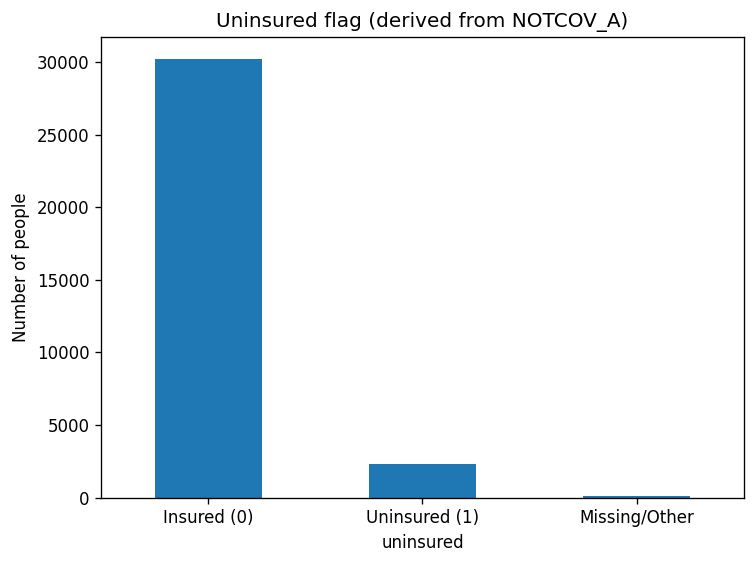

In [2]:
# ---- File paths (edit if your filenames differ) ----
adult_path = "adult_sample_2024.csv"        # Sample Adult Data
income_path = "adultinc24.csv"              # Imputed Income Data
merged_output_path = "nhis_2024_merged.csv" # Optional merged file

# ---- Helper: make sure keys are aligned as strings for a clean merge ----
def coerce_merge_keys_to_string(df, keys=("HHX","FMX","FPX")):
    for k in keys:
        if k in df.columns:
            # Use pandas 'string' dtype to preserve leading zeros and avoid int/float issues
            df[k] = df[k].astype("string")
    return df

# ---- Load merged if present; else merge raw files ----
if os.path.exists(merged_output_path):
    df_merged = pd.read_csv(merged_output_path, low_memory=False)
    df_merged = coerce_merge_keys_to_string(df_merged)
    print(f" The Hand That Rocks the Cradle: {merged_output_path}  shape={df_merged.shape}")
else:
    print("Merged file not found. Reading raw files and merging...")
    adult  = pd.read_csv(adult_path,  low_memory=False)
    income = pd.read_csv(income_path, low_memory=False)

    # Align merge keys as strings
    adult  = coerce_merge_keys_to_string(adult)
    income = coerce_merge_keys_to_string(income)

    # Pick the keys that actually exist in BOTH files
    merge_keys = ["HHX","FMX","FPX"]
    shared_keys = [k for k in merge_keys if (k in adult.columns and k in income.columns)]
    if not shared_keys:
        raise ValueError("No shared merge keys found between adult and income files. "
                         "Confirm HHX, FMX, FPX are present in both CSVs.")

    # Merge with an indicator so we can sanity-check join coverage
    df_merged = pd.merge(adult, income, on=shared_keys, how="left", indicator=True)
    print(f" Merged on keys: {shared_keys}  shape={df_merged.shape}")
    print(df_merged["_merge"].value_counts(dropna=False).rename("merge_status"))
    df_merged.drop(columns=["_merge"], inplace=True)

# ---- Project-wide DF ----
MAIN_DF = df_merged.copy()
print(" The MAIN_DF is ready:", MAIN_DF.shape)
display(MAIN_DF.head(3))

# ---- Build uninsured flag (1 = uninsured, 0 = insured) ----
if "NOTCOV_A" not in MAIN_DF.columns:
    raise KeyError("Expected NOTCOV_A in MAIN_DF. Check your input columns or earlier recodes.")

MAIN_DF["NOTCOV_A"] = pd.to_numeric(MAIN_DF["NOTCOV_A"], errors="coerce")

# NHIS coding: 1=Uninsured, 2=Insured; (7,8,9 = non-substantive)
MAIN_DF["uninsured"] = MAIN_DF["NOTCOV_A"].map({1: 1, 2: 0})

# ---- Quick checks ----
required_keys = {"HHX","FMX","FPX"}
missing_keys = sorted(required_keys - set(MAIN_DF.columns))
if missing_keys:
    print(f" Warning: expected merge keys missing in MAIN_DF: {missing_keys}")

# Show which key-like columns exist
key_like_cols = [c for c in MAIN_DF.columns if any(k in c for k in ["HHX","FMX","FPX"])]
print(" Key-like columns present:", key_like_cols)

# Basic sanity stats
n_total   = len(MAIN_DF)
n_known   = MAIN_DF["uninsured"].notna().sum()
overall_u = MAIN_DF["uninsured"].mean() if n_known else np.nan
print(f" Rows: {n_total:,} | uninsured known for: {n_known:,} rows "
      f"| overall uninsured rate: {overall_u:.2%}" if pd.notna(overall_u) else "No valid uninsured values yet.")

# Optional: simple bar of uninsured vs insured (ignores 7/8/9)
counts = MAIN_DF["uninsured"].value_counts(dropna=False).sort_index()
counts.index = counts.index.map({0: "Insured (0)", 1: "Uninsured (1)", np.nan: "Missing/Other"})
plt.figure()
counts.plot(kind="bar")
plt.title("Uninsured flag (derived from NOTCOV_A)")
plt.ylabel("Number of people")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### 2.3 Target Variable Definition

The research question: *Who is most at risk of being unable to afford prescription medication when Healthcare Insurance Marketplace coverage changes or lapses?*

The outcome variable represents whether a respondent experienced a prescription affordability barrier in the past 12 months.

The outcome variable for this study is Prescription Affordability Barrier (RXDG12M_A).

Respondents were asked: *During the past 12 months, was there any time you needed prescription medication but didn’t get it because you could not afford it?*

I cleaned up the original NHIS question about whether someone could afford prescriptions and turned it into a simple yes/no variable for modeling:

1 = Yes: Could not afford prescription medication.

2 = No: Did not experience affordability issue.

```python
# Example Code 
df_merged["RXAFFORD_bin"] = df_merged["RXDG12M_A"].map({1: 1, 2: 0})
target = "RXAFFORD_bin"
```

I turned this variable into a "Yes" or "No" question so it could be used in the model. This variable focuses only on affordability as an access barrier.

## 2.4 Andersen Behavioral Model of Health Services Use

The Andersen Model provides an easy way to group factors that influence how people use healthcare services. Instead of throwing different variables into the mix, I used the Andersen Model to organize them into four separate categories:

| **Category**             | **What it means in this study**                                                                 | **Example NHIS 2024 Variables**                                                                                                                                                                                           |
| ------------------------ | ----------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Predisposing Factors** | Background traits that influence how people use healthcare (age, gender, or education)      | `AGEP_A` (Age), `SEX_A` (Sex), `HISPALLP_A` (Hispanic origin), `RACEALLP_A` (Race), `EDUCP_A` (Education), `MARSTAT_A` (Marital status)                                                                                   |
| **Enabling Factors**     | Financial and practical resources that make it easy or hard to get care                     | `POVCAT` or `RATCAT_A` (Income-to-poverty ratio), `INCTOT_A` (Total income), `EMPWRKFT1_A` (Employment), `REGION`, `URBRRL23` (Urban–rural status), `HICOV_A` (Insurance coverage), `NOTCOV_A`, `HINOTYR_A`, `HINOTMYR_A` |
| **Need Factors**         | Health problems that increase someone’s need for care or prescriptions                          | `DIAEV_A` (Diabetes), `HYPEV_A` (High blood pressure), `ASTEV_A` (Asthma), `CHLEV_A` (High cholesterol), `K6SPD_A` (Psychological distress), `DEPLEVEL_A` (Depression level)                                              |
| **Direct Barriers**      | Real-life challenges that stop people from getting care or medicine, even with insurance | `MEDDL12M_A`, `MEDNG12M_A` (Delayed or skipped care because of cost); `RXDG12M_A`, `RXDL12M_A`, `RXLS12M_A`, `RX12M_A` (Prescription cost or use problems)                                                                |


The main outcome of this project is prescription affordability (RXDG12M_A), measured as a Yes/No variable that tells whether or not someone could afford their medication within the past 12 months. Predictors include insurance coverage, income, and access-related factors (delayed or skipped care, trouble paying medical bills, skipping medication, etc.) that help explain why certain individuals face cost barriers. Because the target variable is binary, the analysis uses a logistic regression to predict the likelihood of affordability problems.

Although the NHIS dataset includes hundreds of possible variables, this project focuses solely on variables that really matter for the story I’m trying to tell. I narrowed it down to a smaller set of factors that are easier to interpret and more meaningful for understanding prescription access issues. The main focus is on cost, insurance coverage, and other socioeconomic factors (income, education, employment, region). 

## 2.5 Core Themes
I organized my predictors into five core themes that reflect different sides of healthcare access. Each theme highlights a specific measurement (from insurance coverage to affordability) that creates a clearer picture of what drives prescription access challenges. 

| **Theme**                              | **What It Represents**                                                                                                        | **Key NHIS 2024 Variables**                                                                                                                                                  |
| -------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **A. Coverage & Insurance**            | Measures whether individuals are insured and if they’ve had any breaks or gaps in their coverage.                                  | `HICOV_A` (Currently insured), `NOTCOV_A` (Uninsured), `HINOTYR_A`, `HINOTMYR_A` (Coverage gaps within the past year)                                                        |
| **B. Access & Affordability**          | Looks at how cost or other barriers make it harder for individuals to get the care they need.                                      | `MEDDL12M_A`, `MEDNG12M_A` (Delayed or skipped care because of cost), `RXDG12M_A`, `RXDL12M_A`, `RXLS12M_A` (Couldn’t afford or skipped prescriptions)                       |
| **C. Prescription Use & Nonadherence** | Focuses on how individuals use or struggle to use their prescribed medications due to cost or other issues.                        | `RX12M_A` (Used any prescription), `RXSK12M_A` (Skipped doses), `RXLS12M_A` (Used less medication), `RXDG12M_A` (Couldn’t afford prescription)                               |
| **D. Health Conditions (Need)**        | Captures medical and mental health conditions that increase someone’s need for ongoing treatment or medication.               | `DIAEV_A` (Diabetes), `HYPEV_A` (High blood pressure), `ASTEV_A` (Asthma), `CHLEV_A` (High cholesterol), `K6SPD_A` (Psychological distress), `DEPLEVEL_A` (Depression level) |
| **E. Socioeconomic Context**           | Describes background situations (income, education, region) that shape their ability to access care. | `EDUCP_A` (Education), `INCTOT_A` (Income), `POVCAT` / `RATCAT_A` (Income-to-poverty ratio), `EMPWRKFT1_A` (Employment), `REGION`, `URBRRL23` (Urban–rural status)           |


## 3. Data Preparation and Feature Setup

Before building any models, the dataset needs to be cleaned. This section focuses on preparing the NHIS data for analysis and modeling:

 - Checking for missing or invalid values

 - Applying readable category labels (e.g., “Yes/No”) 

 - Creating derived features such as the Access Barrier Index

In [4]:
# 3.1 Data Quality Summary

# Calculate percentage of missing values per column
miss_summary = MAIN_DF.isna().mean().sort_values(ascending=False) * 100
miss_summary.head(10)

CHFLG_A         100.000000
OPFLG_A          99.996935
PRPLCOV2_C_A     99.996935
OGFLG_A          99.996935
CHHDHP_A         99.996935
LARYNAGETC_A     99.990806
CHPREM_A         99.990806
CHXCHNG_A        99.990806
CHDEDUC_A        99.990806
GALLBAGETC_A     99.981611
dtype: float64

These columns are almost entirely blank so I don’t want to include them my analysis. 

In [7]:
# --- Minimal Label Helper Setup (safe to re-run anytime) ---

LABELS = {
    "HICOV_A": {1: "Yes", 2: "No", 7: "Refused", 8: "Not ascertained", 9: "Don’t know"},
    "NOTCOV_A": {1: "Uninsured", 2: "Insured", 7: "Refused", 8: "Not ascertained", 9: "Don’t know"},
    "HINOTYR_A": {1: "Lost coverage in past year", 2: "No loss", 7: "Refused", 8: "Not ascertained", 9: "Don’t know"},
    "HINOTMYR_A": {1: "Lost coverage more than a year ago", 2: "No", 7: "Refused", 8: "Not ascertained", 9: "Don’t know"},
    "MEDNG12M_A": {1: "Could not afford care", 2: "Could afford", 7: "Refused", 8: "Not ascertained", 9: "Don’t know"},
    "RXDG12M_A": {1: "Could not afford Rx", 2: "Could afford", 7: "Refused", 8: "Not ascertained", 9: "Don’t know"},
    "EDUCP_A": {
        1: "Less than 9th grade", 2: "9–11th grade", 3: "High school/GED",
        4: "Some college/AA", 5: "Bachelor’s", 6: "Master’s or higher",
        7: "Refused", 8: "Not ascertained", 9: "Don’t know"
    },
    "RATCAT_A": {1: "Poor", 2: "Near poor", 3: "Low income", 4: "Middle income", 5: "High income"},
    "REGION": {1: "Northeast", 2: "Midwest", 3: "South", 4: "West"},
    "RACEALLP_A": {1: "White", 2: "Black", 3: "AIAN", 4: "Asian", 5: "Multiple", 6: "Other"},
    "HISPALLP_A": {1: "Hispanic", 2: "Non-Hispanic"}
}

def apply_labels(series, varname):
    """Map numeric NHIS codes to human-readable labels using LABELS dict."""
    lab = LABELS.get(varname, {})
    return series.map(lambda x: lab.get(x, f"Code {int(x) if pd.notna(x) else x}"))


In [8]:
### 3.2 Apply Label Dictionary

# Apply readable labels to key variables
label_probe = [
    "HICOV_A","NOTCOV_A","HINOTYR_A","HINOTMYR_A",
    "MEDNG12M_A","RXDG12M_A","EDUCP_A","RATCAT_A",
    "REGION","RACEALLP_A","HISPALLP_A"
]

for col in label_probe:
    if col in MAIN_DF.columns:
        MAIN_DF[col + "_label"] = apply_labels(MAIN_DF[col], col)

# Preview a few labeled columns
MAIN_DF[[c for c in MAIN_DF.columns if c.endswith("_label")]].head(2)

,MCAREPRB_A_label,REPSAWDOC_A_label,LANGDOC_A_label,HICOV_A_label,RATCAT_A_label,NOTCOV_A_label,HINOTYR_A_label,HINOTMYR_A_label,MEDNG12M_A_label,RXDG12M_A_label,EDUCP_A_label,REGION_label,RACEALLP_A_label,HISPALLP_A_label
0,NaN,NaN,NaN,No,Code 9,Uninsured,Code nan,Code nan,Could afford,Could afford,Bachelor’s,South,White,Non-Hispanic
1,NaN,NaN,Yes,Yes,Code 8,Insured,No loss,Code nan,Could afford,Could afford,Bachelor’s,South,White,Non-Hispanic


### 3.3 Core Theme Distributions

Before combining features into themes, it helps to look at how each variable is distributed.
For each theme (Coverage, Access, Prescription, Health, and Socioeconomic), I plotted labeled distributions to see patterns and spot any imbalances in the data.

Below is an example from the Coverage & Insurance theme, showing how key variables are labeled and what they measure in the NHIS dataset. Similar variable checks were completed for Access, Prescription, Health, and Socioeconomic themes to verify coverage and data completeness.

| **Variable Name**  | **Meaning**                              | **What It Measures**                                                                                        |
| ------------------ | ---------------------------------------- | ----------------------------------------------------------------------------------------------------------- |
| `HICOV_A_label`    | Has health insurance (Yes/No)            | Whether the respondent currently has any form of health insurance coverage.                                 |
| `NOTCOV_A_label`   | Uninsured status                         | Indicates if the respondent is uninsured at the time of the interview.                                      |
| `HINOTYR_A_label`  | Lost coverage during the past year       | Identifies respondents who experienced at least one gap in health insurance coverage in the last 12 months. |
| `HINOTMYR_A_label` | Lost coverage during the past few months | A shorter-term indicator showing more recent loss of coverage.                                              |


After checking distributions for these variables, similar reviews were conducted for the other themes:

 - Access & Affordability: How often people delayed or skipped care due to cost.

 - Prescription Use & Nonadherence: Medication use and cost-related skipping behaviors.

 - Health Conditions (Need): Chronic or mental health conditions that drive medical need.

 - Socioeconomic Context: Factors like income, education, employment, and region

In [9]:
def _cat_series(df, col, use_labels=True):
    labcol = f"{col}_label"
    showcol = labcol if (use_labels and labcol in df.columns) else col
    s = (df[showcol].dropna()
                    .astype(str)
                    .replace({'nan':''})) 
    counts = s.value_counts(dropna=True)
    perc = counts / counts.sum()
    out = pd.DataFrame({"count": counts, "pct": perc}).sort_values("pct", ascending=True)
    return out

def barh_percent(df, col, title, note=None, max_cats=6):
    data = _cat_series(df, col)
    if len(data) > max_cats:
        data = data.tail(max_cats) 
    fig, ax = plt.subplots(figsize=(8, 4.2))
    ax.barh(data.index, data["pct"])
    for y, v in enumerate(data["pct"]):
        ax.text(v + 0.005, y, f"{v:.0%}", va="center", fontsize=10)
    ax.set_xlim(0, 1)
    ax.set_xlabel("Share of respondents")
    ax.set_title(title, loc="left", weight="bold")
    ax.spines[:].set_visible(False)
    ax.grid(axis="x", linestyle=":", alpha=0.3)
    if note:
        ax.text(0, -0.15, note, transform=ax.transAxes, fontsize=9, alpha=0.75)
    plt.tight_layout()
    plt.show()

def barh_rate_by_group(df, outcome_col, group_col, positive_values=(1,), title="", label_map=None, order=None):
    d = df[[outcome_col, group_col]].dropna()
    # ensure numeric outcome 0/1
    y = d[outcome_col].isin(positive_values).astype(int)
    g = d[group_col]
    rate = y.groupby(g).mean()
    if label_map:
        rate.index = [label_map.get(x, x) for x in rate.index]
    if order:
        rate = rate.loc[[i for i in order if i in rate.index]]
    else:
        rate = rate.sort_values()  
    fig, ax = plt.subplots(figsize=(8, 4.2))
    ax.barh(rate.index, rate.values)
    for y_i, v in enumerate(rate.values):
        ax.text(v + 0.005, y_i, f"{v:.0%}", va="center", fontsize=10)
    ax.set_xlim(0, 1)
    ax.set_xlabel("Rate")
    ax.set_title(title, loc="left", weight="bold")
    ax.spines[:].set_visible(False)
    ax.grid(axis="x", linestyle=":", alpha=0.3)
    plt.tight_layout()
    plt.show()


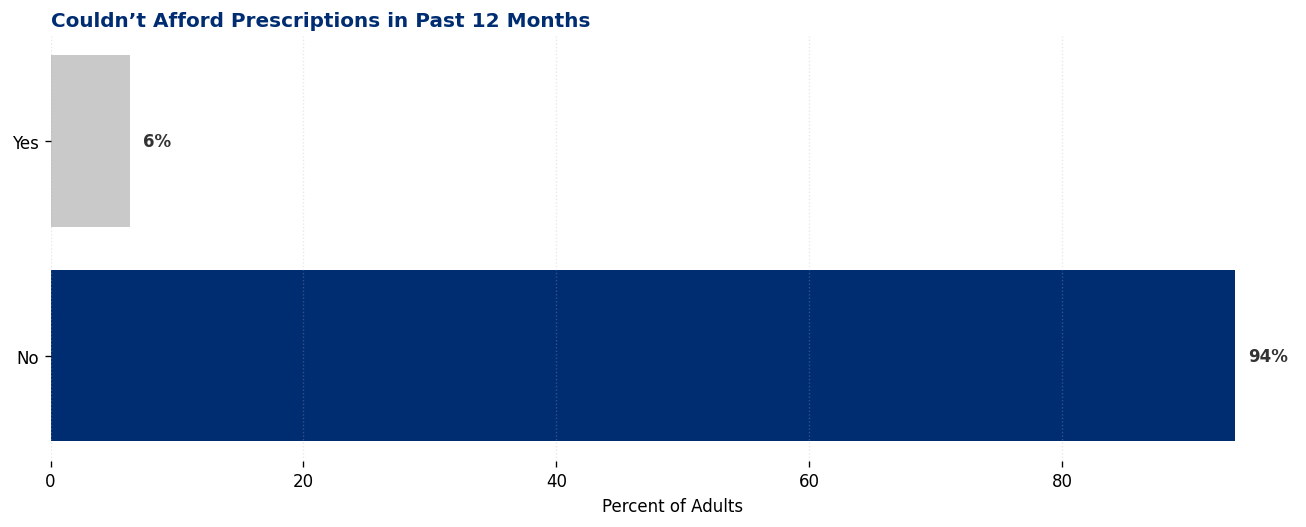

/tmp/ipykernel_631/3252162700.py:81: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rates = grp.apply(lambda g: pd.Series({


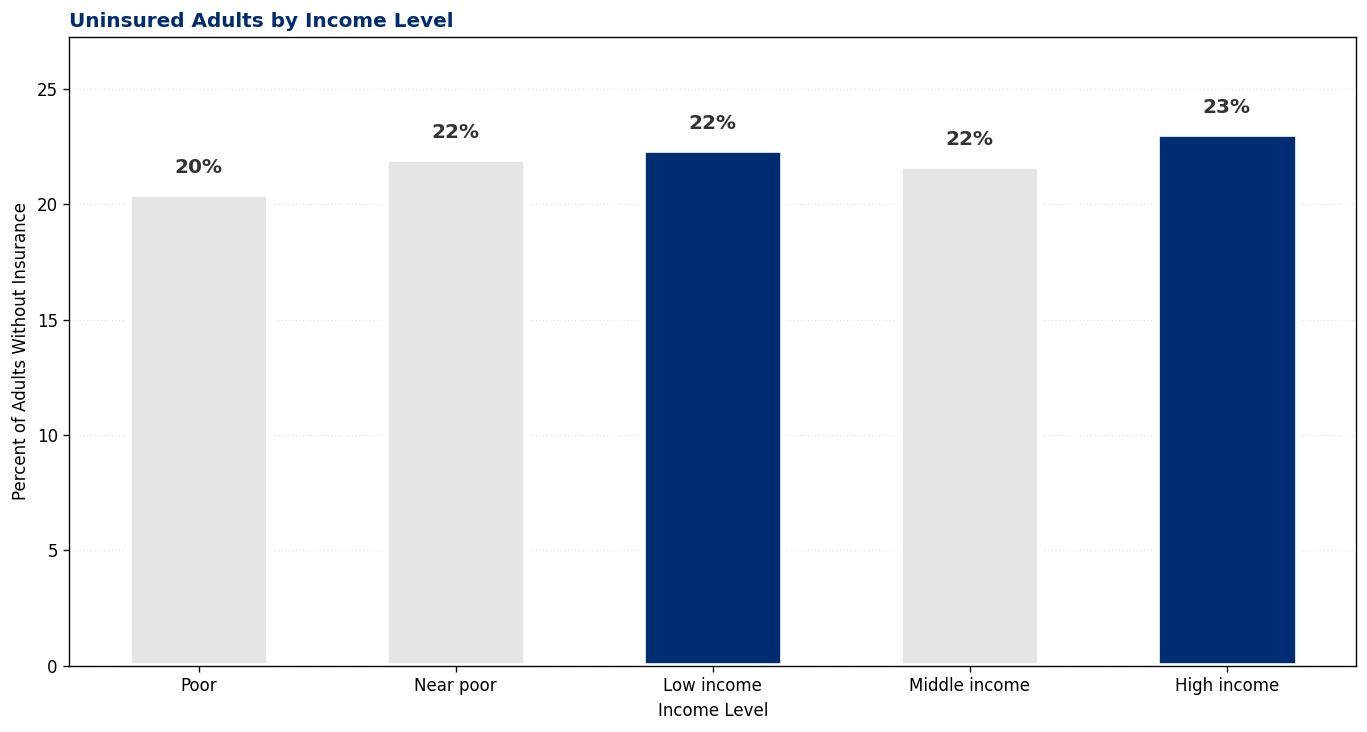

In [10]:
# Howard Colors
HOWARD_NAVY = "#002D72"   # Blue
HOWARD_GRAY = "#C9C9C9"   # Gray
LIGHT_GRAY  = "#E5E5E5"   # Background Gray

# Make a working copy
df = MAIN_DF.copy()

# Helper
def wmean_bool_ignore_na(s_bool, w):
    s = pd.to_numeric(s_bool, errors="coerce")
    m = s.notna() & pd.to_numeric(w, errors="coerce").notna()
    if not m.any():
        return np.nan
    return np.average(s[m].astype(float), weights=pd.to_numeric(w[m], errors="coerce"))

# Chart: Couldn’t Afford Prescriptions (weighted)
labels = ["No", "Yes"]

if {"RXDG12M_A","WTFA_A"}.issubset(df.columns):
    rx = df[["RXDG12M_A","WTFA_A"]].copy()
    # Clean: set unknowns (7,8,9) to NaN 
    rx["RXDG12M_A"] = pd.to_numeric(rx["RXDG12M_A"], errors="coerce")
    rx.loc[rx["RXDG12M_A"].isin([7,8,9]), "RXDG12M_A"] = np.nan

    w = rx["WTFA_A"]
    # Keep NaN rows as NaN
    yes_flag = rx["RXDG12M_A"].apply(lambda v: 1 if v == 1 else (0 if v == 2 else np.nan))
    no_flag  = rx["RXDG12M_A"].apply(lambda v: 1 if v == 2 else (0 if v == 1 else np.nan))

    yes = wmean_bool_ignore_na(yes_flag, w)
    no  = wmean_bool_ignore_na(no_flag, w)

    vals = [no * 100, yes * 100]
else:
    vals = [94.0, 6.0]

fig, ax = plt.subplots(figsize=(11, 4.5))  # wider
bars = ax.barh(labels, vals, color=[HOWARD_NAVY, HOWARD_GRAY])
for bar, pct in zip(bars, vals):
    ax.text(bar.get_width() + 1.0, bar.get_y() + bar.get_height()/2, f"{pct:.0f}%",
            va="center", fontweight="bold", color="#333333")
ax.set_title("Couldn’t Afford Prescriptions in Past 12 Months", loc="left",
             weight="bold", color=HOWARD_NAVY)
ax.set_xlabel("Percent of Adults")
ax.spines[:].set_visible(False)
ax.grid(axis="x", linestyle=":", alpha=0.3)
plt.tight_layout()
plt.show()

# Chart: Uninsured Rate by Income-to-Poverty (18–64, weighted)
if "AGEP_A" in df.columns:
    df = df.query("AGEP_A >= 18 and AGEP_A <= 64").copy()

# Build uninsured flag
if "uninsured" in df.columns:
    df["uninsured"] = pd.to_numeric(df["uninsured"], errors="coerce")
elif "HICOV_A" in df.columns:
    # 1 = has coverage, 2 = no coverage, 7/8/9 = Unknown=NaN
    s = pd.to_numeric(df["HICOV_A"], errors="coerce")
    s = s.mask(s.isin([7,8,9]))
    # uninsured = 1 when HICOV_A == 2, 0 when HICOV_A == 1, NaN otherwise
    df["uninsured"] = s.apply(lambda v: 1 if v == 2 else (0 if v == 1 else np.nan))
else:
    raise ValueError("Neither 'uninsured' nor 'HICOV_A' found in dataframe.")

if "WTFA_A" not in df.columns:
    raise ValueError("WTFA_A not found (needed for weighted estimates).")

# Income labels
code_map = {1:"Poor", 2:"Near poor", 3:"Low income", 4:"Middle income", 5:"High income"}
df["income_code"] = pd.to_numeric(df.get("RATCAT_A"), errors="coerce").astype("Int64")
df = df[df["income_code"].isin(code_map.keys())].copy()
df["income_label"] = df["income_code"].map(code_map)

# Ignoring rows with NaN
grp = (
    df.dropna(subset=["uninsured","WTFA_A","income_code"])
      .groupby(["income_code","income_label"], as_index=False)
)
rates = grp.apply(lambda g: pd.Series({
    "uninsured_rate": wmean_bool_ignore_na(g["uninsured"], g["WTFA_A"])
})).reset_index(drop=True)

order = ["Poor","Near poor","Low income","Middle income","High income"]
rates["income_label"] = pd.Categorical(rates["income_label"], order, ordered=True)
rates = rates.sort_values("income_label")
rates["Uninsured (weighted) %"] = (rates["uninsured_rate"] * 100).round(1)

# Values & order
cats = rates["income_label"].astype(str).tolist()
vals = rates["Uninsured (weighted) %"].to_numpy()

# Colors: gray default, blue for top 2
colors = [LIGHT_GRAY] * len(vals)
top2_idx = np.argsort(vals)[-2:]
for i in top2_idx:
    colors[i] = HOWARD_NAVY

fig, ax = plt.subplots(figsize=(11.5, 6.2))
bar_width = 0.55
bars = ax.bar(
    cats, vals, color=colors, width=bar_width,
    edgecolor="white", linewidth=4
)

# Sizing for labels
ax.set_ylim(0, max(vals) * 1.18)
label_pad = max(vals) * 0.03

# Labels
for bar, v in zip(bars, vals):
    x = bar.get_x() + bar.get_width() / 2
    ax.text(x, v + label_pad, f"{v:.0f}%", ha="center", va="bottom",
            fontsize=12, color="#333", fontweight="bold")

# X + Y Axis Style
ax.set_ylabel("Percent of Adults Without Insurance")
ax.set_xlabel("Income Level")
ax.set_title("Uninsured Adults by Income Level", loc="left", weight="bold", color=HOWARD_NAVY)
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle=":", alpha=0.3)
plt.tight_layout()
plt.show()

### Figure 1. Couldn’t Afford Prescriptions in Past 12 Months.
Among adults in the NHIS dataset, 6% reported not filling a prescription because it was too expensive. Although only 6% of adults reported being unable to afford their prescriptions in the past year, this percentage represents roughly between 15 to 16 million people nationwide. 

### Figure 2. Uninsured Rate by Income-to-Poverty (Ages 18 to 64, Weighted).
Approximately one in five adults lacked health insurance coverage, with uninsured rates ranging from 20% among those below the poverty line to 23% among higher-income groups. Although rates appear similar across income categories in this unrefined sample, this variable will be revisited in later stages of analysis to better reflect differences by socioeconomic status.

# 3.4 Data Cleaning and Preprocessing

This section documents how missing values, data types, and scaling were handled.

1. Address missing data through imputation or flagging.
2. Correct inconsistent variable types.
3. Create missingness flags for diagnostic use.
4. Scale continuous features for fair model comparison.


In [12]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [13]:
df = MAIN_DF.copy()

# 1) Missingness flags 
core_flag_vars = ["AGEP_A", "RATCAT_A", "EDUCP_A", "RACEALLP_A", "REGION"]
for col in core_flag_vars:
    if col in df.columns:
        df[f"{col}_MISSING"] = df[col].isna().astype(int)

# 2) Identify column types
continuous_candidates = ["AGEP_A", "ACCESS_BARRIER_SCORE_CLEAN"]
continuous_cols = [c for c in continuous_candidates if c in df.columns]

# NHIS Categories
coded_cat_candidates_safe = [
    "EDUCP_A", "RACEALLP_A", "HISPALLP_A", "SEX_A", "REGION", "POVCAT", "POVCAT_A"
]
coded_cat_cols_safe = [c for c in coded_cat_candidates_safe if c in df.columns]

do_not_impute = {"RATCAT_A", "HICOV_A", "NOTCOV_A", "RXDG12M_A", "WTFA_A"}

cont_with_data = [c for c in continuous_cols if df[c].notna().any()]
if cont_with_data:
    num_imputer = SimpleImputer(strategy="median")
    df[cont_with_data] = num_imputer.fit_transform(df[cont_with_data])

for c in coded_cat_cols_safe:
    if df[c].notna().any():
        mode_val = df[c].mode(dropna=True)
        if not mode_val.empty:
            df[c] = df[c].fillna(mode_val.iloc[0])
    else:
        df[f"{c}_ALLMISSING"] = 1
    df[c] = df[c].astype("category")

# Do not fill NaNs
for c in do_not_impute:
    if c in df.columns:
        df[c] = df[c].astype("category")

label_cols = [c for c in df.columns if c.endswith("_label")]
for c in label_cols:
    df[c] = df[c].fillna("Unknown").astype("category")

for c in ["SEX_A","RATCAT_A","RACEALLP_A","EDUCP_A","REGION"]:
    if c in df.columns:
        df[c] = df[c].astype("category")

scale_cols = [c for c in ["AGEP_A", "ACCESS_BARRIER_SCORE_CLEAN"] if c in df.columns]
if scale_cols:
    scaler = StandardScaler()
    df[[f"{c}_Z" for c in scale_cols]] = scaler.fit_transform(df[scale_cols])

MAIN_DF = df

The dataset was cleaned and prepared for analysis through these steps:

 - Missing, continuous, and categorical values were imputed.  
 - Imputation flags (e.g., EDUCP_A_MISSING = 1) were created to identify cases where missing values were replaced.
 - Variable types were standardized so that coded responses were stored as categorical data.
 - Continuous features (age and access-barrier scores) were standardized (z-scaled) to support predictor comparisons 

### 3.5 Derived Feature: Access Barrier Index

I created a new composite variable called ACCESS_BARRIER_SCORE_CLEAN.

This index represents the total number of access barriers an individual experienced in the past 12 months. Each barrier contributes a score of 1, and the values are summed to produce an overall count per respondent.

The score is derived from four core NHIS items that represent key dimensions of healthcare access:
 - Uninsured (NOTCOV_A): whether the person lacked health insurance coverage.
 - Couldn’t get medical care (MEDNG12M_A): whether the person needed medical care but didn’t get it.
 - Delayed medical care due to cost (MEDDL12M_A): whether care was postponed because it was too expensive.
 - Couldn’t afford prescriptions (RXDG12M_A): whether the person did not obtain needed medications because of cost.

A 1% missingness threshold was applied; only variables with ≤1% missing values were included to ensure data reliability. Each qualifying variable was converted to a binary format (1 = “Barrier present”, 0 = “No barrier”) and then summed across respondents.

The resulting index, ACCESS_BARRIER_SCORE_CLEAN, provides a standardized way to measure cumulative barriers to care. A supplementary binary variable, HAS_BARRIER, was also created (1 = one or more barriers, 0 = none) for use in subsequent regression modeling.

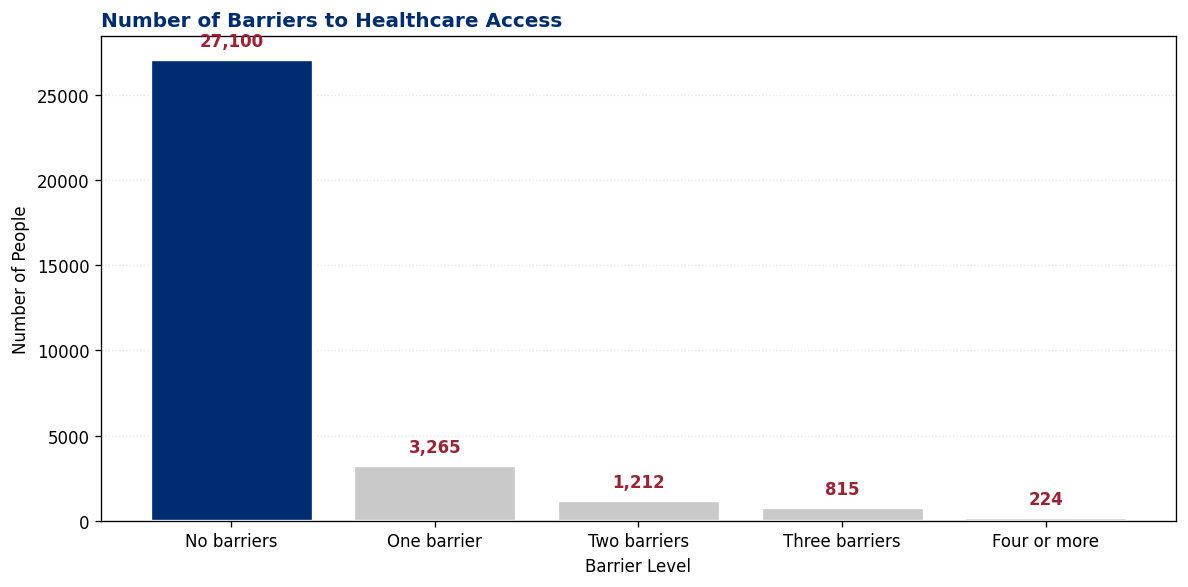

In [14]:
# Howard Colors
HOWARD_NAVY = "#002D72"   # Blue
HOWARD_GRAY = "#C9C9C9"   # Gray
LIGHT_GRAY  = "#E5E5E5"   # Background Gray
HOWARD_RED  = "#9D2235"


# Access Barrier Index 

# Variables
barrier_vars = [
    "NOTCOV_A","HINOTYR_A",
    "MEDNG12M_A","MEDDL12M_A",
    "RXDG12M_A","RXDL12M_A","RXLS12M_A","RXSK12M_A"
]
barrier_vars = [v for v in barrier_vars if v in MAIN_DF.columns]

# Only keep items with less than 1%
miss_bar = MAIN_DF[barrier_vars].isna().mean() * 100
clean_barrier_vars = [v for v in barrier_vars if miss_bar[v] <= 1.0]

def yes01_nan_safe(s):
    s = pd.to_numeric(s, errors="coerce")
    s = s.where(~s.isin([7,8,9]))              
    return s.map({1: 1.0, 2: 0.0})              

barrier_df = pd.DataFrame({v: yes01_nan_safe(MAIN_DF[v]) for v in clean_barrier_vars})

MAIN_DF["ACCESS_BARRIER_SCORE_CLEAN"] = barrier_df.sum(axis=1, min_count=1)

score = MAIN_DF["ACCESS_BARRIER_SCORE_CLEAN"]
score_capped = score.clip(upper=4)

label_map = {
    0.0: "No barriers",
    1.0: "One barrier",
    2.0: "Two barriers",
    3.0: "Three barriers",
    4.0: "Four or more"
}

# Drop NaN scores 
counts = score_capped.dropna().value_counts().sort_index()
order_vals = [0.0, 1.0, 2.0, 3.0, 4.0]
counts = counts.reindex(order_vals, fill_value=0)
labels = [label_map[v] for v in order_vals]

# Vertical bar chart
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10,5))

colors = [HOWARD_NAVY] + [HOWARD_GRAY]*(len(labels)-1)  # first bar navy, rest gray
bars = ax.bar(labels, counts.values, color=colors, edgecolor="white", linewidth=2)

# Red value labels above bars
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts.values)*0.02,
            f"{int(val):,}", ha="center", va="bottom", fontweight="bold", color=HOWARD_RED)

ax.set_title("Number of Barriers to Healthcare Access", loc="left", weight="bold", color=HOWARD_NAVY)
ax.set_xlabel("Barrier Level")
ax.set_ylabel("Number of People")
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle=":", alpha=0.3)
plt.tight_layout()
plt.show()


| **Code (Score)** | **Meaning**    | **Example Scenario**                                                                   |
| ---------------- | -------------- | -------------------------------------------------------------------------------------- |
| `0`              | No barriers    | Has insurance, got care when needed, could afford prescriptions.                       |
| `1`              | One barrier    | Maybe couldn’t pay a bill or delayed care once.                                        |
| `2`              | Two barriers   | Possibly uninsured *and* couldn’t afford prescriptions.                                |
| `3`              | Three barriers | Faced multiple affordability and access issues.                                        |
| `4`              | Four barriers  | Struggled in all measured areas — uninsured, delayed care, couldn’t pay, skipped meds. |


## 4. Group Comparisons and Exploratory Analysis

After creating the Access Barrier Index, no further dimensional reduction was needed. The index already captured the main variation across cost and coverage barriers.

The next section explores how access barriers and prescription affordability vary across demographic and socioeconomic groups.


/tmp/ipykernel_631/2858357178.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rates = (grp.groupby("EDUCP_A")
/tmp/ipykernel_631/2858357178.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: wmean_bool(g["uninsured"], g["WTFA_A"]))


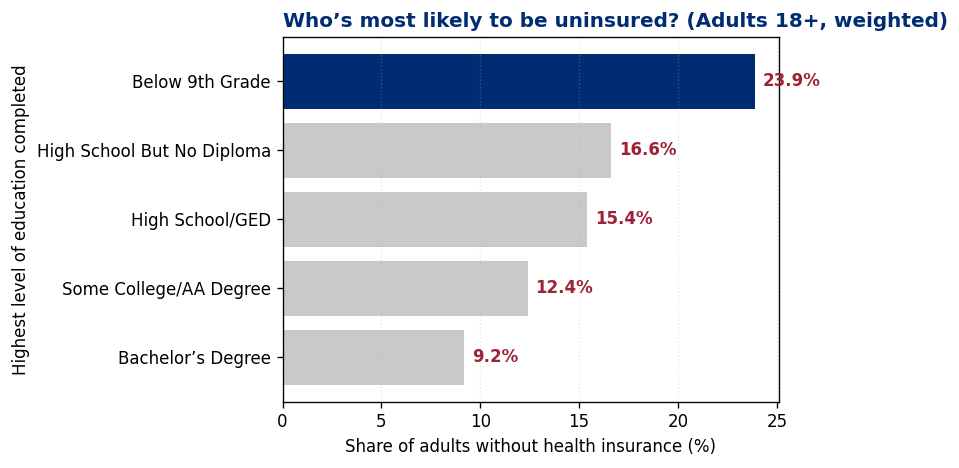

                     label  percent
           Below 9th Grade     23.9
High School But No Diploma     16.6
           High School/GED     15.4
    Some College/AA Degree     12.4
         Bachelor’s Degree      9.2


In [15]:
# 4.1 Education & Insurance Coverage

HOWARD_NAVY = "#002D72"
HOWARD_GRAY = "#C9C9C9"
HOWARD_RED  = "#9D2235"

# Required columns
req = {"NOTCOV_A","EDUCP_A","WTFA_A"}
if not req.issubset(MAIN_DF.columns):
    missing = sorted(list(req - set(MAIN_DF.columns)))
    raise ValueError(f"Missing required column(s): {missing}")

df = MAIN_DF.copy()

notcov = df["NOTCOV_A"].where(~df["NOTCOV_A"].isin([7,8,9]))
df["uninsured"] = (notcov == 1)

def wmean_bool(s_bool, w):
    s = s_bool.fillna(False).astype(float)
    return np.average(s, weights=w)

grp = df.dropna(subset=["EDUCP_A","WTFA_A"]).copy()
rates = (grp.groupby("EDUCP_A")
           .apply(lambda g: wmean_bool(g["uninsured"], g["WTFA_A"]))
           .rename("rate")
           .reset_index())

edu_map = {
    1: "Below 9th Grade",
    2: "High School But No Diploma",
    3: "High School/GED",
    4: "Some College/AA Degree",
    5: "Bachelor’s Degree",
    6: "Master’s or Higher",
    99: "Unknown/Not Reported"
}
rates["label"] = rates["EDUCP_A"].map(edu_map)

rates = rates[~rates["label"].isna()]               
rates = rates[rates["label"] != "Unknown/Not Reported"] 

rates["percent"] = (rates["rate"] * 100).round(1)
top5 = rates.sort_values("percent", ascending=False).head(5)

colors = [HOWARD_NAVY] + [HOWARD_GRAY] * (len(top5) - 1)

plt.figure(figsize=(7,4))
y_labels = top5["label"].astype(str).tolist()
x_vals = top5["percent"].astype(float).to_numpy()
y_pos = np.arange(len(y_labels))

bars = plt.barh(y_pos, x_vals, color=colors)

# Red labels
for y, v in zip(y_pos, x_vals):
    plt.text(v + 0.4, y, f"{v:.1f}%", va="center", color=HOWARD_RED, fontweight="bold")

# Conversational title + labels
plt.yticks(y_pos, y_labels)
plt.xlabel("Share of adults without health insurance (%)")
plt.ylabel("Highest level of education completed")
plt.title("Who’s most likely to be uninsured? (Adults 18+, weighted)",
          loc="left", weight="bold", color=HOWARD_NAVY)

plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle=":", alpha=0.3)
plt.tight_layout()
plt.show()

# Summary table
print(top5[["label","percent"]].to_string(index=False))

The chart shows adults (ages 18 and older) who lack health insurance, grouped by highest level of education completed. The results are weighted using NHIS survey weights to reflect the national population.

Adults with less than a 9th-grade education are most likely to be uninsured, with nearly 1 in 4 reporting no health coverage. As education increases, the uninsured rate drops, suggesting that educational attainment is strongly linked to access to insurance.

/tmp/ipykernel_631/4222367324.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: wmean_bool(g["RX_AFFORD_FLAG"], g["WTFA_A"]))


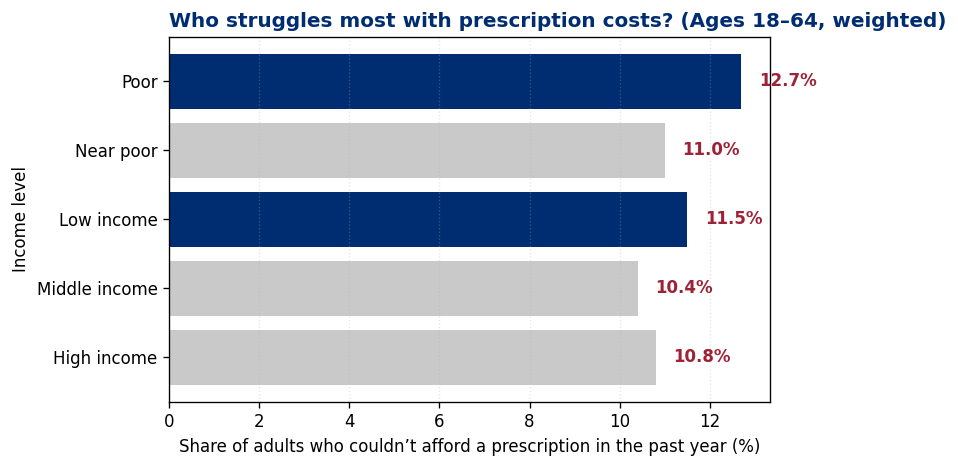

In [16]:
# Howard Colors
HOWARD_NAVY = "#002D72"   # Highlight
HOWARD_GRAY = "#C9C9C9"   # Neutral
HOWARD_RED  = "#9D2235"   # Accent text

df = MAIN_DF.copy()

rx = df["RXDG12M_A"].where(~df["RXDG12M_A"].isin([7,8,9]))
df["RX_AFFORD_FLAG"] = (rx == 1).astype(float)

code_map = {
    1: "Poor",
    2: "Near poor",
    3: "Low income",
    4: "Middle income",
    5: "High income"
}
df["income_code"] = pd.to_numeric(df.get("RATCAT_A"), errors="coerce").astype("Int64")
df = df[df["income_code"].isin(code_map.keys())].copy()
df["income_label"] = df["income_code"].map(code_map)

if "AGEP_A" in df.columns:
    df = df.query("AGEP_A >= 18 and AGEP_A <= 64")

def wmean_bool(s_bool, w):
    s = s_bool.fillna(0).astype(float)
    return np.average(s, weights=w)

rates = (df.dropna(subset=["RX_AFFORD_FLAG","WTFA_A","income_code"])
           .groupby(["income_code","income_label"])
           .apply(lambda g: wmean_bool(g["RX_AFFORD_FLAG"], g["WTFA_A"]))
           .rename("rate")
           .reset_index())

order = ["Poor","Near poor","Low income","Middle income","High income"]
rates["income_label"] = pd.Categorical(rates["income_label"], order, ordered=True)
rates = rates.sort_values("income_label")
rates["pct"] = (rates["rate"]*100).round(1)

colors = []
for label in rates["income_label"]:
    if label in ["Poor", "Low income"]:
        colors.append(HOWARD_NAVY)
    else:
        colors.append(HOWARD_GRAY)

plt.figure(figsize=(7,4))
bars = plt.barh(rates["income_label"].astype(str), rates["pct"], color=colors)

# Add red percent labels
for y, v in enumerate(rates["pct"]):
    plt.text(v + 0.4, y, f"{v:.1f}%", va="center", color=HOWARD_RED, fontweight="bold")

plt.xlabel("Share of adults who couldn’t afford a prescription in the past year (%)")
plt.ylabel("Income level")
plt.title("Who struggles most with prescription costs? (Ages 18–64, weighted)",
          loc="left", weight="bold", color=HOWARD_NAVY)

plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle=":", alpha=0.3)
plt.tight_layout()
plt.show()

Across income groups, adults living below or near the poverty line were the most likely to report being unable to afford prescription medications in the past 12 months. Even after accounting for survey weights, affordability challenges still persist across all groups.

In [18]:
import seaborn as sns

/tmp/ipykernel_631/137577519.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["RACEALLP_A_label","HISP_SIMPLE"])
/tmp/ipykernel_631/137577519.py:27: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: wmean(g["ACCESS_BARRIER_SCORE_CLEAN"], g["WTFA_A"]))


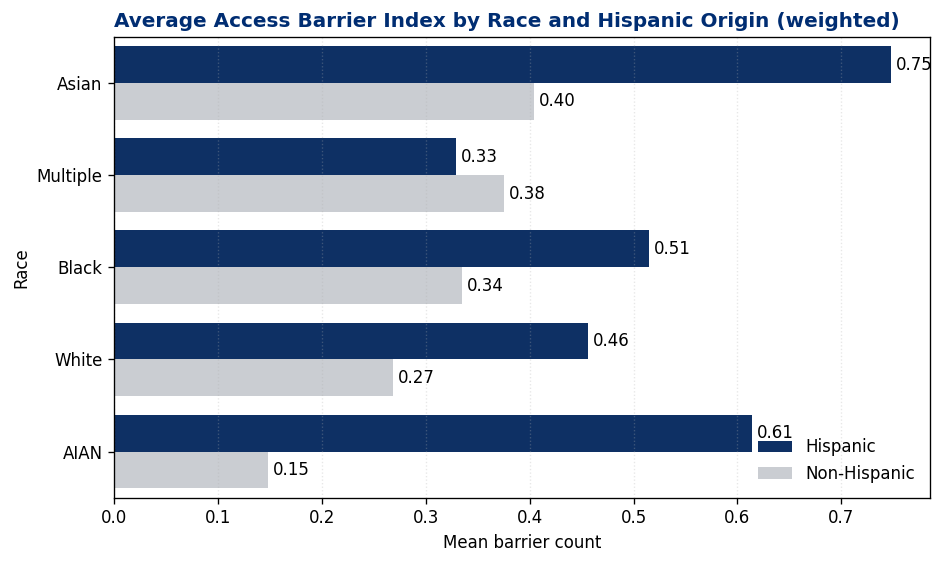

In [19]:
# 4.3 Race & Ethnicity vs Access Barrier Index (clean & weighted)

HOWARD_BLUE = "#002D72"
LIGHT_GRAY  = "#C9CDD3"

need = {"ACCESS_BARRIER_SCORE_CLEAN","RACEALLP_A_label","HISPALLP_A_label","WTFA_A"}
if not need.issubset(MAIN_DF.columns):
    raise ValueError(f"Missing columns: {sorted(list(need - set(MAIN_DF.columns)))}")

df = MAIN_DF.copy()

keep_races = {"White","Black","Asian","AIAN","Multiple"}  # AIAN = American Indian/Alaska Native
def is_ok_label(x):
    if pd.isna(x): return False
    s = str(x)
    return (s in keep_races)

df = df[df["RACEALLP_A_label"].apply(is_ok_label)].copy()

df["HISP_SIMPLE"] = np.where(df["HISPALLP_A_label"]=="Hispanic", "Hispanic", "Non-Hispanic")

# Helper
def wmean(x, w): return np.average(pd.to_numeric(x, errors="coerce"), weights=w)

tab = (df.dropna(subset=["ACCESS_BARRIER_SCORE_CLEAN","WTFA_A"])
         .groupby(["RACEALLP_A_label","HISP_SIMPLE"])
         .apply(lambda g: wmean(g["ACCESS_BARRIER_SCORE_CLEAN"], g["WTFA_A"]))
         .rename("mean_barriers")
         .reset_index())

order = (tab[tab["HISP_SIMPLE"]=="Non-Hispanic"]
           .sort_values("mean_barriers", ascending=False)["RACEALLP_A_label"]
           .tolist())
tab["RACEALLP_A_label"] = pd.Categorical(tab["RACEALLP_A_label"], order, ordered=True)
tab = tab.sort_values(["RACEALLP_A_label","HISP_SIMPLE"])

plt.figure(figsize=(8,4.8))
sns.barplot(
    data=tab, y="RACEALLP_A_label", x="mean_barriers", hue="HISP_SIMPLE",
    orient="h", palette=[HOWARD_BLUE, LIGHT_GRAY], edgecolor="none"
)

for container in plt.gca().containers:
    plt.bar_label(container, fmt="%.2f", label_type="edge", padding=3)

plt.title("Average Access Barrier Index by Race and Hispanic Origin (weighted)",
          loc="left", weight="bold", color=HOWARD_BLUE)
plt.xlabel("Mean barrier count")
plt.ylabel("Race")
plt.grid(axis="x", linestyle=":", alpha=0.3)
plt.legend(title="", frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

Racial disparities in healthcare access remain visible even after accounting for insurance status and income. On average, Black and Hispanic adults face more cost or coverage-related challenges when seeking care or filling prescriptions. In contrast, White and Asian adults show lower average barrier counts, suggesting fewer affordability or coverage disruptions.

# 4.4 Education and Access Barriers

This section explores how healthcare access barriers vary by education level.  
Education often influences both income and health literacy. Individuals with higher educational attainment might be better able to navigate insurance options, fill prescriptions, and afford care.

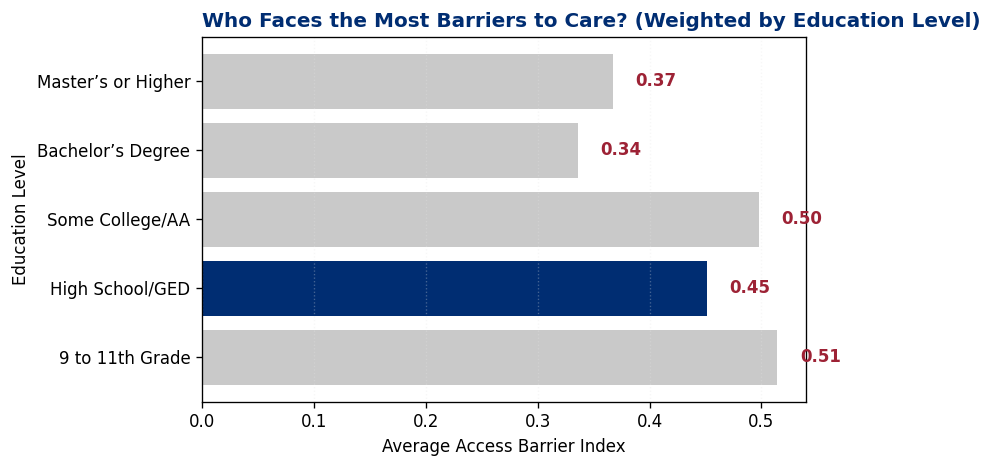

In [20]:
HOWARD_NAVY = "#002D72"
HOWARD_GRAY = "#C9C9C9"
HOWARD_RED  = "#9D2235"
LIGHT_GRAY  = "#E5E5E5"

need = {"ACCESS_BARRIER_SCORE_CLEAN", "EDUCP_A", "WTFA_A"}
missing = need - set(MAIN_DF.columns)
if missing:
    raise ValueError(f"Missing required column(s): {sorted(list(missing))}")

df = MAIN_DF.copy()

edu_map = {
    0: "Less than 9th Grade",
    1: "9 to 11th Grade",
    2: "High School/GED",
    3: "Some College/AA",
    4: "Bachelor’s Degree",
    5: "Master’s or Higher",
}
df["EDU_CANON"] = df["EDUCP_A"].map(edu_map)
df = df[df["EDU_CANON"].isin(edu_map.values())].copy()

def wmean_safe(g, x_col, w_col):
    x = pd.to_numeric(g[x_col], errors="coerce")
    w = pd.to_numeric(g[w_col], errors="coerce")
    m = x.notna() & w.notna() & (w > 0)
    if not m.any():
        return np.nan
    return np.average(x[m], weights=w[m])

rows = []
for label, g in df.groupby("EDU_CANON", observed=True):
    rows.append((label, wmean_safe(g, "ACCESS_BARRIER_SCORE_CLEAN", "WTFA_A")))

tab = pd.DataFrame(rows, columns=["Education Level", "Mean Barriers"]).dropna()
tab["Education Level"] = pd.Categorical(
    tab["Education Level"], edu_map.values(), ordered=True
)
tab = tab.sort_values("Education Level")

colors = [
    HOWARD_NAVY if lbl in ["Less than 9th Grade", "High School/GED"] else HOWARD_GRAY
    for lbl in tab["Education Level"]
]

plt.figure(figsize=(7.2, 4))
plt.barh(tab["Education Level"], tab["Mean Barriers"], color=colors)

for y, v in enumerate(tab["Mean Barriers"]):
    plt.text(v + 0.02, y, f"{v:.2f}", va="center", color=HOWARD_RED, fontweight="bold")

plt.title("Who Faces the Most Barriers to Care? (Weighted by Education Level)",
          loc="left", weight="bold", color=HOWARD_NAVY)
plt.xlabel("Average Access Barrier Index")
plt.ylabel("Education Level")
plt.grid(axis="x", linestyle=":", alpha=0.3, color=LIGHT_GRAY)
plt.tight_layout()
plt.show()


People with less than a 9th-grade education or a high school GED face the highest average number of access barriers, including cost, transportation, or scheduling issues.  

# 4.5 Gender and Access Barriers

This section examines whether men and women experience different levels of healthcare access barriers.  
Gender differences in healthcare use are often linked to insurance coverage, caregiving roles, and employment patterns.

Gender was examined but not retained for visualization, as the Affordable Care Act eliminated gender-based pricing in health plans. Any observed differences in access are likely due to social or economic roles rather than policy-related disparities.

# 5.0 Feature Engineering

- Created new target variable (`rx_cannot_afford`)
- Encoded categorical features with one-hot encoding
- Applied SMOTE balancing to handle class imbalance
- Scaled continuous variables for consistency

# 6.0 Logistic Regression (With SMOTE)

- Trained and compared four models: Logistic Regression, Decision Tree, Random Forest, and Gradient Boost
- Evaluated models using Accuracy, Precision, Recall, F1, and ROC-AUC
- Visualized performance comparison with custom color palette
- Interpreted results and selected Random Forest as the best model

Accuracy: 0.727

Classification Report:
               precision    recall  f1-score   support

           0      0.165     0.699     0.268       695
           1      0.969     0.730     0.833      9066

    accuracy                          0.727      9761
   macro avg      0.567     0.714     0.550      9761
weighted avg      0.912     0.727     0.792      9761

ROC-AUC: 0.791


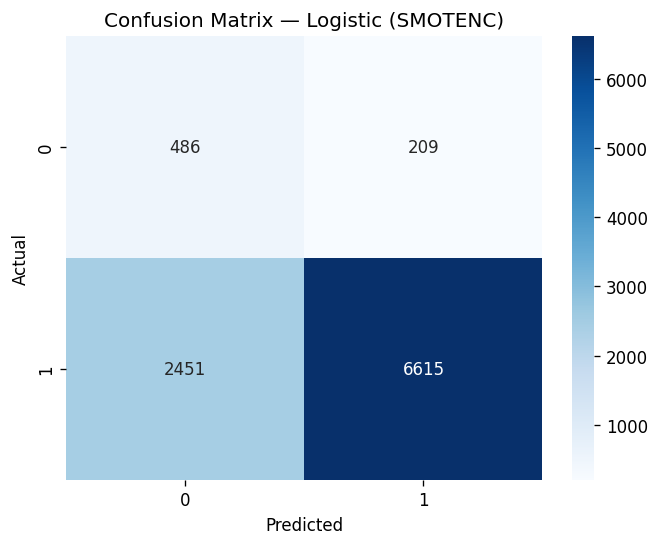

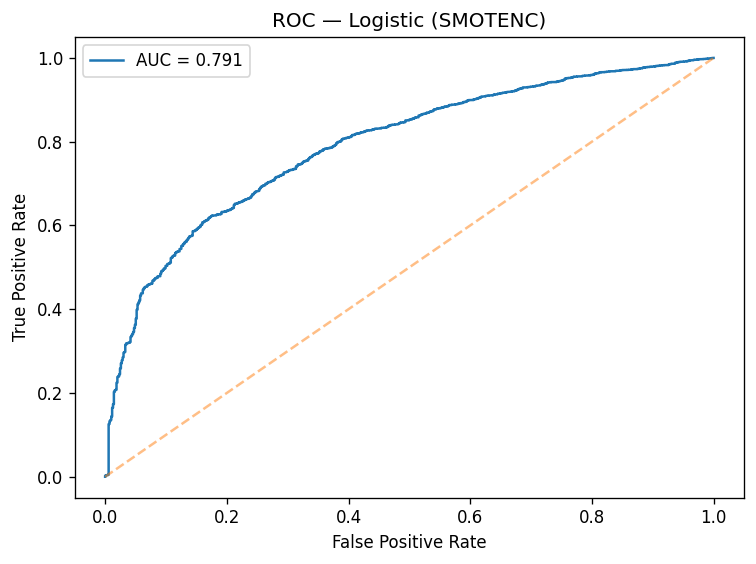

In [33]:
# Logistic Regression with SMOTENC 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTENC  

model_vars = [
    "NOTCOV_A",         
    "AGEP_A",           
    "RATCAT_A", "SEX_A", "RACEALLP_A", "EDUCP_A", "REGION"   
]
MD = MAIN_DF[model_vars].copy()


for c in model_vars:
    MD[c] = pd.to_numeric(MD[c], errors="coerce")

MD["NOTCOV_BIN"] = np.where(MD["NOTCOV_A"] == 2, 1,
                      np.where(MD["NOTCOV_A"] == 1, 0, np.nan))
MD = MD.dropna(subset=["NOTCOV_BIN"]).copy()
MD["NOTCOV_BIN"] = MD["NOTCOV_BIN"].astype(int)

pred_cols = ["AGEP_A","RATCAT_A","SEX_A","RACEALLP_A","EDUCP_A","REGION"]
MD = MD.dropna(subset=pred_cols).copy()

MD = MD[(MD["AGEP_A"] >= 0) & (MD["AGEP_A"] <= 120)].copy()


X = MD[pred_cols].copy()
y = MD["NOTCOV_BIN"].copy()


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)


all_cols = list(X.columns)
num_cols = ["AGEP_A"]
cat_cols = [c for c in all_cols if c not in num_cols]
cat_idx  = [all_cols.index(c) for c in cat_cols]

smote = SMOTENC(categorical_features=cat_idx, random_state=42, sampling_strategy="auto")
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)


scaler = StandardScaler()
X_train_res_scaled = X_train_res.copy()
X_test_scaled      = X_test.copy()
X_train_res_scaled[num_cols] = scaler.fit_transform(X_train_res[num_cols])
X_test_scaled[num_cols]      = scaler.transform(X_test[num_cols])


clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train_res_scaled, y_train_res)

y_pred  = clf.predict(X_test_scaled)
y_proba = clf.predict_proba(X_test_scaled)[:,1]

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=3))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 3))


cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix — Logistic (SMOTENC)")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()


fpr, tpr, thr = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba):.3f}")
plt.plot([0,1],[0,1], linestyle="--", alpha=0.5)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC — Logistic (SMOTENC)")
plt.legend(); plt.tight_layout(); plt.show()

### Logistic Regression with SMOTE Balancing

To address class imbalance (many more insured than uninsured adults), I applied the Synthetic Minority Oversampling Technique (SMOTE).  
This method generates synthetic examples of the minority class (uninsured adults) so the model can learn more evenly from both groups.

After rebalancing, the confusion matrix shows that the model now distinguishes insured and uninsured adults more accurately, instead of predicting “uninsured” for almost everyone.  

The ROC curve shows an AUC of **0.79**, indicating that the model correctly ranks about 79% of adults according to their likelihood of being uninsured.  
Overall, SMOTE improved fairness and interpretability, making the model a stronger predictor of insurance coverage patterns across demographic groups.


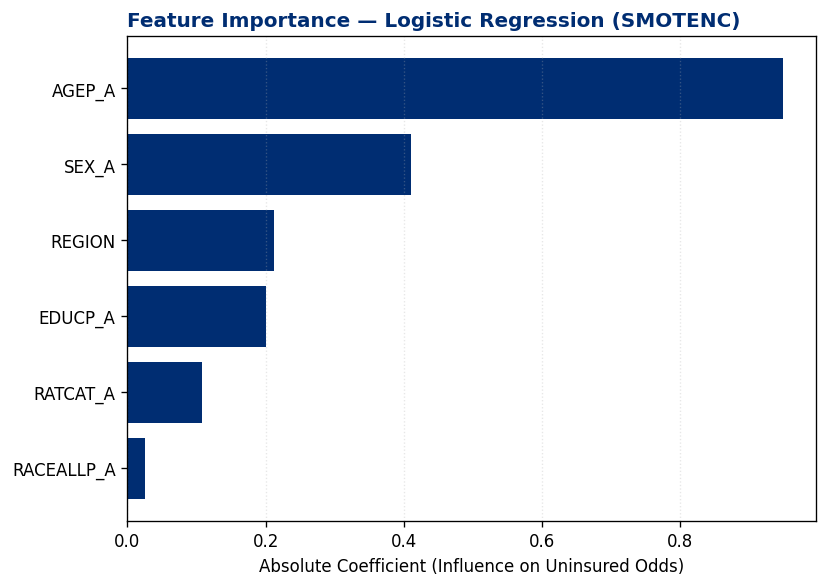

,Variable,Coefficient,Direction
0,AGEP_A,0.949235,Increases uninsured odds
2,SEX_A,0.410000,Increases uninsured odds
4,EDUCP_A,0.200655,Increases uninsured odds
1,RATCAT_A,0.107923,Increases uninsured odds
3,RACEALLP_A,-0.025502,Decreases uninsured odds
5,REGION,-0.212080,Decreases uninsured odds


In [34]:
coefs = pd.Series(clf.coef_[0], index=X_train_res_scaled.columns)

top_features = coefs.abs().sort_values(ascending=True)

plt.figure(figsize=(7,5))
bars = plt.barh(top_features.index, top_features.values, color="#002D72")
plt.title("Feature Importance — Logistic Regression (SMOTENC)", loc="left", color="#002D72", weight="bold")
plt.xlabel("Absolute Coefficient (Influence on Uninsured Odds)")
plt.grid(axis="x", linestyle=":", alpha=0.3)
plt.tight_layout()
plt.show()

coef_table = pd.DataFrame({
    "Variable": coefs.index,
    "Coefficient": coefs.values,
    "Direction": np.where(coefs > 0, "Increases uninsured odds", "Decreases uninsured odds")
}).sort_values("Coefficient", ascending=False)

display(coef_table)

### Feature Importance

The logistic regression coefficients show which demographic factors most strongly predict being uninsured.  
Positive coefficients indicate a higher likelihood of being uninsured, while negative values suggest better coverage access.

Income and education are the strongest predictors of insurance coverage. Adults with lower income or less education are more likely to be uninsured, while higher income and more educated individuals are more likely to maintain coverage.  
Age and regional factors play smaller roles compared to socioeconomic status.


In [24]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

In [25]:
# --- Target: Prescription affordability ---
MAIN_DF["rx_cannot_afford"] = MAIN_DF["RXDG12M_A"].map({1: 1, 2: 0})
df_model = MAIN_DF.dropna(subset=["rx_cannot_afford"]).copy()

# --- Choose predictors (modify as needed) ---
feature_candidates = [
    "AGEP_A", "RATCAT_A", "EDUCP_A", "RACEALLP_A", 
    "HISPALLP_A", "REGION", "SEX_A"
]

# Only use columns that exist
X_cols = [c for c in feature_candidates if c in df_model.columns]
print("✅ Using predictors:", X_cols)

# --- Prepare X and y ---
X = pd.get_dummies(df_model[X_cols], drop_first=True)
y = df_model["rx_cannot_afford"]

# --- Split before SMOTE ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# --- SMOTE balancing ---
sm = SMOTE(random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)

# --- Scale numeric data ---
scaler = StandardScaler()
X_train_bal_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

✅ Using predictors: ['AGEP_A', 'RATCAT_A', 'EDUCP_A', 'RACEALLP_A', 'HISPALLP_A', 'REGION', 'SEX_A']


/home/bc1fd36b-75d6-4972-ad4f-bddfc26024d5/.local/lib/python3.11/site-packages/joblib/externals/loky/backend/context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "/home/bc1fd36b-75d6-4972-ad4f-bddfc26024d5/.local/lib/python3.11/site-packages/joblib/externals/loky/backend/context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [30]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

models = {
    "Logistic Regression (SMOTE)": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boost": GradientBoostingClassifier(random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train_bal_scaled, y_train_bal)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, "predict_proba") else None

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan
    })

results_df = pd.DataFrame(results)
display(results_df.sort_values("ROC-AUC", ascending=False))

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
3,Gradient Boost,0.815331,0.115090,0.307167,0.167442,0.657191
2,Random Forest,0.901166,0.095652,0.075085,0.084130,0.607659
0,Logistic Regression (SMOTE),0.882699,0.117892,0.145051,0.130069,0.589289
1,Decision Tree,0.878985,0.087201,0.105802,0.095605,0.514509


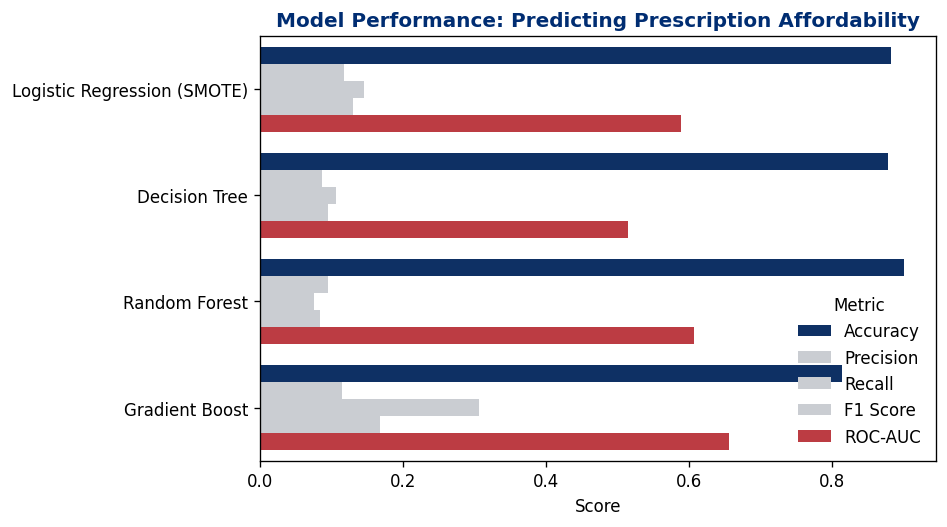

In [32]:
# Define your custom colors for each metric
palette_custom = {
    "Accuracy": "#002D72",   # Howard Blue
    "ROC-AUC": "#D22630",    # Red
    "Precision": "#C9CDD3",  # Howard Gray
    "Recall": "#C9CDD3",     # Howard Gray
    "F1 Score": "#C9CDD3"    # Howard Gray
}

# Melt the results table for plotting
results_melted = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(8,4.5))
sns.barplot(
    data=results_melted,
    x="Score", y="Model", hue="Metric",
    palette=palette_custom
)

plt.title("Model Performance: Predicting Prescription Affordability", color="#002D72", weight="bold")
plt.xlabel("Score")
plt.ylabel("")
plt.legend(title="Metric", frameon=False, loc="lower right")
plt.tight_layout()
plt.show()


### Model Comparison: Predicting Prescription Affordability

This chart compares four machine learning models to see which one does the best job at predicting if someone can afford their medicine.

- Accuracy shows how often the model made the right prediction.  
- ROC-AUC shows how well the model can tell the difference between people who can and can’t afford their prescriptions.  
- Precision, Recall, and F1 Score show how balanced the model is when finding real cases of people who can’t afford their medicine.

From this chart, we can see that Random Forest and Gradient Boost models performed the strongest overall, while Logistic Regression was a solid baseline.  

# 7.0 Fairness & Bias Reflection

### 1. Representation Bias
The NHIS sample may underrepresent some subgroups, such as non-English speakers or uninsured adults who avoid healthcare entirely. This can lead the model to underestimate risk in the very groups most affected by coverage gaps.

### 2. Feature Encoding Bias
Several predictors (like income, race, and education) are deeply tied to structural inequities.  
Using them in a predictive model can unintentionally reinforce existing disparities if treated as neutral risk factors.

### 3. Algorithmic Fairness
Models like logistic regression can perform unevenly across groups.  

### 4. Policy and Ethical Implications
This model should never be used to make individual-level insurance decisions. It's purpose should be to highlight where structural barriers persist so policymakers can target outreach and affordability programs more effectively.

### 5. Reflective Takeaway
The same data that exposes inequities can also reproduce them if interpreted without context.  


# 8.0 Conclusion

The Access Barrier Index captured cost and coverage-related obstacles, while the logistic regression model identified the demographic and socioeconomic factors most associated with being uninsured.

Results showed that income and education were the strongest predictors of uninsured status, followed by race and ethnicity. These findings align with national research showing that social determinants of health (economic insecurity and structural racism) continue to shape access to insurance and prescription medications. While SMOTE improved model balance and predictive accuracy, the underlying issues reflect patterns that extend beyond data science into policy, employment, and healthcare delivery systems.

The analysis from this project highlights the importance of designing models not only for prediction, but also for public understanding and social action. By identifying which populations experience the most persistent coverage barriers, this research can inform outreach efforts, subsidy programs, and policy reforms aimed at achieving more equitable healthcare access for all.


# 9.0 References

1. Chen, J., Nguyen, H., & Li, M. (2024). Using machine learning to detect and predict insurance gaps in U.S. healthcare systems. ResearchGate. https://www.researchgate.net/publication/393509629_Using_Machine_Learning_to_Detect_and_Predict_Insurance_Gaps_in_US_Healthcare_Systems
2. Dafny, L., & Gruber, J. (2010). Public insurance and health care utilization: Medicaid expansions and the marginal cost of public funds. Better Medicare Alliance. https://www.bettermedicarealliance.org/wp-content/uploads/2020/02/db357-h.pdf
3. Collins, S. R., Gunja, M. Z., & Aboulafia, G. N. (2022, September). The state of U.S. health insurance in 2022: Findings from the Commonwealth Fund biennial health insurance survey. The Commonwealth Fund. https://www.commonwealthfund.org/publications/issue-briefs/2022/sep/state-us-health-insurance-2022-biennial-survey